In [2]:
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt

In [3]:
# Here, we define the control points.
grid = torch.linspace(-1, 1, steps=10)

# we take the entire domain to plot the basis function as a function of x
x = torch.linspace(-1, 1, steps=1000)

print(f"Grid: Shape:{grid.shape}, values:", grid)
print(f"x: Shape:{x.shape}, values:", x[:5])

# Reshape so that each x can be compared to each control point
grid_ = grid.unsqueeze(dim=0)
x_ = x.unsqueeze(dim=1)

# Base case
k = 0
value1 = (x_ >= grid_[:,:-1]) * (x_ < grid_[:, 1:])

# Other cases
k = 1 # This gives us basis functions for order 1
value21 = (x_ - grid_[:, :-(k+1)]) / (grid_[:, 1:-k] - grid_[:, :-(k+1)]) * value1[:, :-1]
value22 = (grid_[:, (k+1):] - x_) / (grid_[:, (k+1):] - grid_[:, 1:-k]) * value1[:, 1:]
value2 = value21 + value22

k = 2 # This gives us basis functions for order 2
value31 = (x_ - grid_[:, :-(k+1)]) / (grid_[:, 1:-k] - grid_[:, :-(k+1)]) * value2[:, :-1]
value32 = (grid_[:, (k+1):] - x_) / (grid_[:, (k+1):] - grid_[:, 1:-k]) * value2[:, 1:]
value3 = value31 + value32

k = 3 # This gives us basis functions for order 3
value41 = (x_ - grid_[:, :-(k+1)]) / (grid_[:, 1:-k] - grid_[:, :-(k+1)]) * value3[:, :-1]
value42 = (grid_[:, (k+1):] - x_) / (grid_[:, (k+1):] - grid_[:, 1:-k]) * value3[:, 1:]
value4 = value41 + value42

Grid: Shape:torch.Size([10]), values: tensor([-1.0000, -0.7778, -0.5556, -0.3333, -0.1111,  0.1111,  0.3333,  0.5556,
         0.7778,  1.0000])
x: Shape:torch.Size([1000]), values: tensor([-1.0000, -0.9980, -0.9960, -0.9940, -0.9920])


In [4]:
print(f"k=0, number of basis functions: {value1.shape[-1]}")
print(f"k=1, number of basis functions: {value2.shape[-1]}")
print(f"k=2, number of basis functions: {value3.shape[-1]}")
print(f"k=3, number of basis functions: {value4.shape[-1]}")

k=0, number of basis functions: 9
k=1, number of basis functions: 8
k=2, number of basis functions: 7
k=3, number of basis functions: 6


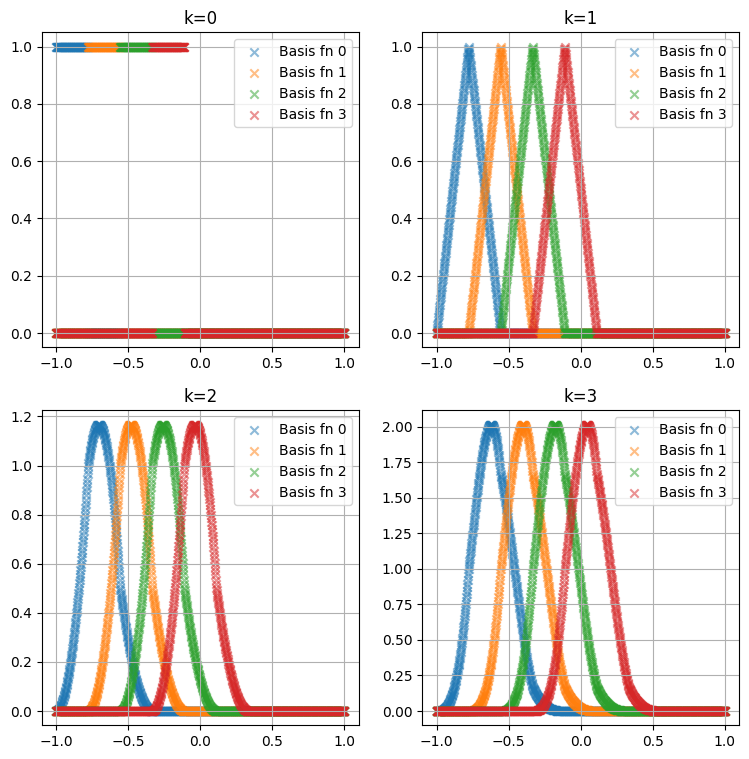

In [5]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(9, 9), dpi=100)

n_basis_to_plot = 4
all_basis = [(value1, 'k=0'), (value2, 'k=1'), (value3, 'k=2'), (value4, 'k=3')]
for i in range(4):

    ax = axs[i // 2, i % 2]

    value, label = all_basis[i]
    for idx in range(value.shape[-1])[:n_basis_to_plot]:
        ax.scatter(x, value[:, idx], marker='x', label=f"Basis fn {idx}", alpha=0.5)
    ax.grid()
    ax.set_title(label)
    ax.legend()

In [6]:
import collections
# value3 is [number of samples, number of basis functions]
# we check how many of the cols are nonzero corresp. to each sample

value3_counts = collections.Counter(torch.where(value3 !=0)[0].tolist())
value4_counts = collections.Counter(torch.where(value4 !=0)[0].tolist())

print('min non-zero values in k=2: ',min(value3_counts.values()))
print('max non-zero values in k=2: ',max(value3_counts.values()))
print('max non-zero values in k=3: ',max(value4_counts.values()))
print('min non-zero values in k=3: ',min(value4_counts.values()))

min non-zero values in k=2:  1
max non-zero values in k=2:  3
max non-zero values in k=3:  4
min non-zero values in k=3:  1


In [8]:
# extend grid (pseudocode)
grid = torch.linspace(-1, 1, steps=5)
print('old grid:', grid, grid.shape)
k = 2
n_intervals = grid.shape[0] - 1
bucket_size = (grid[-1] - grid[0]) / n_intervals

for i in range(k):
    grid = torch.cat([grid[:1] - bucket_size, grid], dim=0)
    grid = torch.cat([grid, grid[-1:] + bucket_size], dim=0)
print('new grid:', grid, grid.shape)

old grid: tensor([-1.0000, -0.5000,  0.0000,  0.5000,  1.0000]) torch.Size([5])
new grid: tensor([-2.0000, -1.5000, -1.0000, -0.5000,  0.0000,  0.5000,  1.0000,  1.5000,
         2.0000]) torch.Size([9])


In [9]:
def extend_grid(grid, k):
    """
    Extends the grid on either size by k steps

    Args:
        grid: number of splines x number of control points
        k: spline order

    Returns:
        new_grid: number of splines x (number of control points + 2 * k)
    """
    n_intervals = grid.shape[-1] - 1
    bucket_size = (grid[:, -1] - grid[:, 0]) / n_intervals

    for i in range(k):
        grid = torch.cat([grid[:, :1] - bucket_size, grid], dim=-1)
        grid = torch.cat([grid, grid[:, -1:] + bucket_size], dim=-1)

    return grid


In [10]:
def eval_basis_functions(x_eval, grid, k):
    """
    Returns the value of basis functions defiend for order-k splines and control points defined in `grid`.

    Args:
        x_eval: number of samples x number of dimensions
        grid: number of splines x number of control points
        k (scalar): order of spline

    Returns:
        bases: number of samples x number of dimensions x number of basis functions
    """
    grid_ = extend_grid(grid, k)
    # Reshape so that each x can be compared to each control point
    grid_ = grid_.unsqueeze(dim=2)
    x_ = x_eval.unsqueeze(dim=1)

    for idx in range(k+1):
        if idx == 0:
            bases = (x_ >= grid_[:, :-1]) * (x_ < grid_[:, 1:]) * 1.0 # step function; for each x in between the corresponding knots, the value is 1.
        else:
            bases1 = (x_ - grid_[:, :-(idx+1)]) / (grid_[:, 1:-idx] - grid_[:, :-(idx+1)]) * bases[:, :-1]
            bases2 = (grid_[:, (idx+1):] - x_) / (grid_[:, (idx+1):] - grid_[:, 1:-idx]) * bases[:, 1:]
            bases = bases1 + bases2

    return bases.transpose(1, 2) * 1.0

Grid: Shape:torch.Size([10]), values: tensor([-1.0000, -0.7778, -0.5556, -0.3333, -0.1111,  0.1111,  0.3333,  0.5556,
         0.7778,  1.0000])
x: Shape:torch.Size([1000]), values: tensor([-1.0000, -0.9980, -0.9960, -0.9940, -0.9920])
k=0, number of basis functions: 9
k=1, number of basis functions: 10
k=2, number of basis functions: 11
k=3, number of basis functions: 12


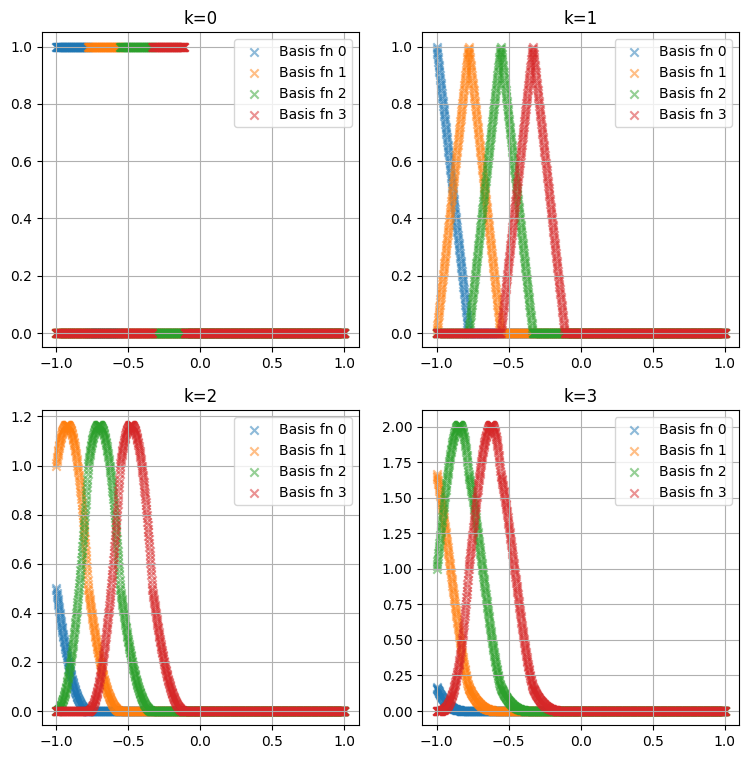

In [11]:
grid = torch.linspace(-1, 1, steps=10)
x = torch.linspace(-1, 1, steps=1000) # we take the entire domain to plot the basis function as a function of x

print(f"Grid: Shape:{grid.shape}, values:", grid)
print(f"x: Shape:{x.shape}, values:", x[:5])

# Reshape so that each x can be compared to each control point
grid_ = grid.unsqueeze(dim=0)
x_ = x.unsqueeze(dim=1)


value1 = eval_basis_functions(x_, grid_, k=0)

value2 = eval_basis_functions(x_, grid_, k=1)

value3 = eval_basis_functions(x_, grid_, k=2)

value4 = eval_basis_functions(x_, grid_, k=3)

print(f"k=0, number of basis functions: {value1.shape[-1]}")
print(f"k=1, number of basis functions: {value2.shape[-1]}")
print(f"k=2, number of basis functions: {value3.shape[-1]}")
print(f"k=3, number of basis functions: {value4.shape[-1]}")


fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(9, 9), dpi=100)

n_basis_to_plot = 4
all_basis = [(value1, 'k=0'), (value2, 'k=1'), (value3, 'k=2'), (value4, 'k=3')]
for i in range(4):

    ax = axs[i // 2, i % 2]

    value, label = all_basis[i]
    for idx in range(value.shape[-1])[:n_basis_to_plot]:
        ax.scatter(x, value[:, 0, idx], marker='x', label=f"Basis fn {idx}", alpha=0.5)
    ax.grid()
    ax.set_title(label)
    ax.legend()

In [12]:
fn = lambda x: torch.sin(torch.pi * x) # define a function that we need to match
coeff1 = torch.linalg.lstsq(value1.squeeze(1), fn(x))

In [13]:
coeff1 # We need to use solution from this object.

torch.return_types.linalg_lstsq(
solution=tensor([-3.3222e-01, -8.4700e-01, -9.6457e-01, -6.2745e-01, -4.5287e-09,
         6.2745e-01,  9.6439e-01,  8.5008e-01,  3.3801e-01]),
residuals=tensor([]),
rank=tensor(9),
singular_values=tensor([]))

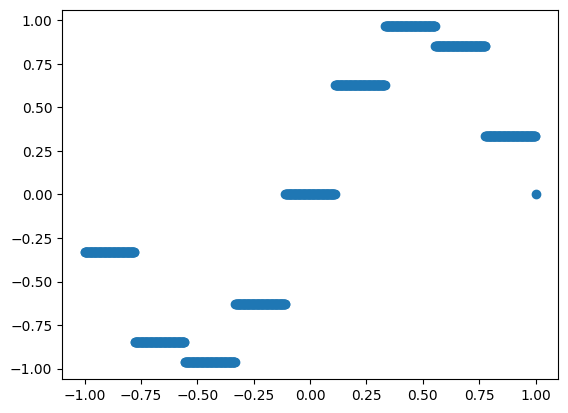

In [14]:
fn = lambda x: torch.sin(torch.pi * x) # define a function that we need to match
coeff1 = torch.linalg.lstsq(value1.squeeze(1), fn(x)).solution # find the coefficients

y_pred = torch.einsum('i, ji -> j', coeff1, value1.squeeze(1)) # use these coefficients to evaluate y
plt.scatter(x, y_pred)

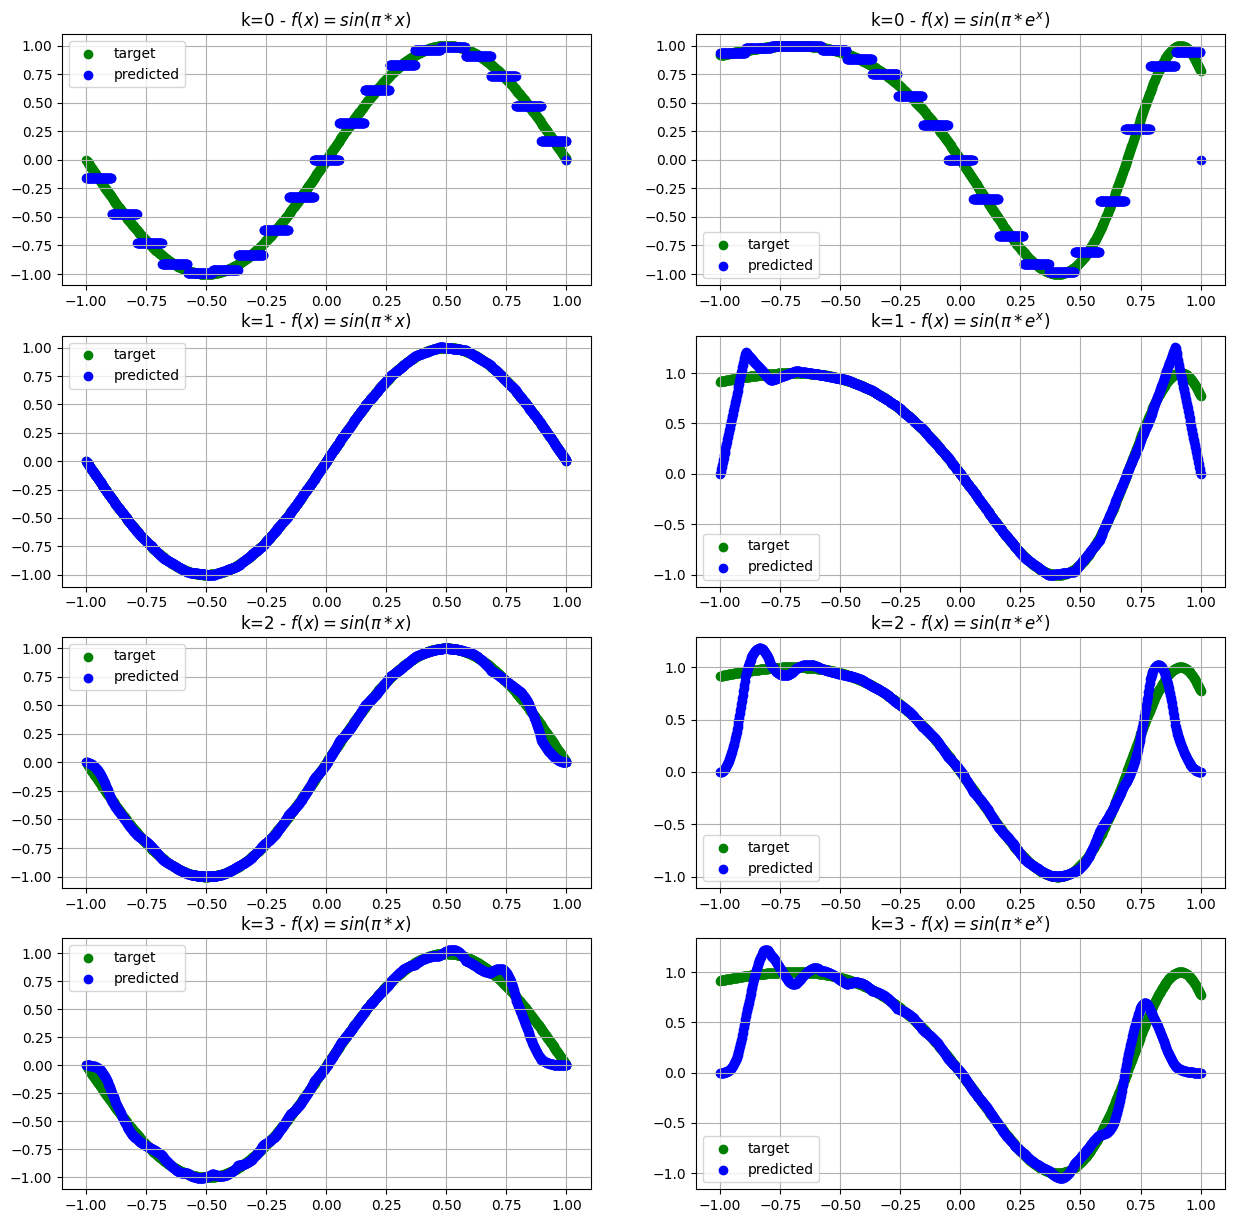

In [15]:
# notice the increase in the grid points to 100
grid = torch.linspace(-1, 1, steps=20)
x = torch.linspace(-1, 1, steps=1000) # we take the entire domain to plot the basis function as a function of x

# Reshape so that each x can be compared to each control point
grid_ = grid.unsqueeze(dim=0)
x_ = x.unsqueeze(dim=1)

k = 0 # This gives us basis functions for order 0
value1 = (x_ >= grid_[:,:-1]) * (x_ < grid_[:, 1:])

k = 1 # This gives us basis functions for order 1
value21 = (x_ - grid_[:, :-(k+1)]) / (grid_[:, 1:-k] - grid_[:, :-(k+1)]) * value1[:, :-1]
value22 = (grid_[:, (k+1):] - x_) / (grid_[:, (k+1):] - grid_[:, 1:-k]) * value1[:, 1:]
value2 = value21 + value22

k = 2 # This gives us basis functions for order 2
value31 = (x_ - grid_[:, :-(k+1)]) / (grid_[:, 1:-k] - grid_[:, :-(k+1)]) * value2[:, :-1]
value32 = (grid_[:, (k+1):] - x_) / (grid_[:, (k+1):] - grid_[:, 1:-k]) * value2[:, 1:]
value3 = value31 + value32

k = 3 # This gives us basis functions for order 3
value41 = (x_ - grid_[:, :-(k+1)]) / (grid_[:, 1:-k] - grid_[:, :-(k+1)]) * value3[:, :-1]
value42 = (grid_[:, (k+1):] - x_) / (grid_[:, (k+1):] - grid_[:, 1:-k]) * value3[:, 1:]
value4 = value41 + value42


fns = []
fns += [(lambda x: torch.sin(torch.pi * x), '$f(x) = sin(\pi*x)$')]
fns += [(lambda x: torch.sin(torch.pi * torch.exp(x)), '$f(x) = sin(\pi*e^{x})$')]

all_basis = [(value1 * 1.0, 'k=0'), (value2, 'k=1'), (value3, 'k=2'), (value4, 'k=3')]

fig, axs = plt.subplots(ncols=len(fns), nrows=len(all_basis), figsize=(15, 15), dpi=100)

for i in range(len(all_basis)):
    for j in range(len(fns)):

        ax = axs[i, j]
        value, label = all_basis[i]
        fn, fn_label = fns[j]

        coeff = torch.linalg.lstsq(value, fn(x)).solution # find the coefficients
        y_pred = torch.einsum('i, ji -> j', coeff, value) # use these coefficients to evaluate y

        ax.scatter(x, fn(x), color='green', label='target')
        ax.scatter(x, y_pred, color='blue', label="predicted")

        ax.grid()
        ax.set_title(f"{label} - {fn_label}")
        ax.legend()

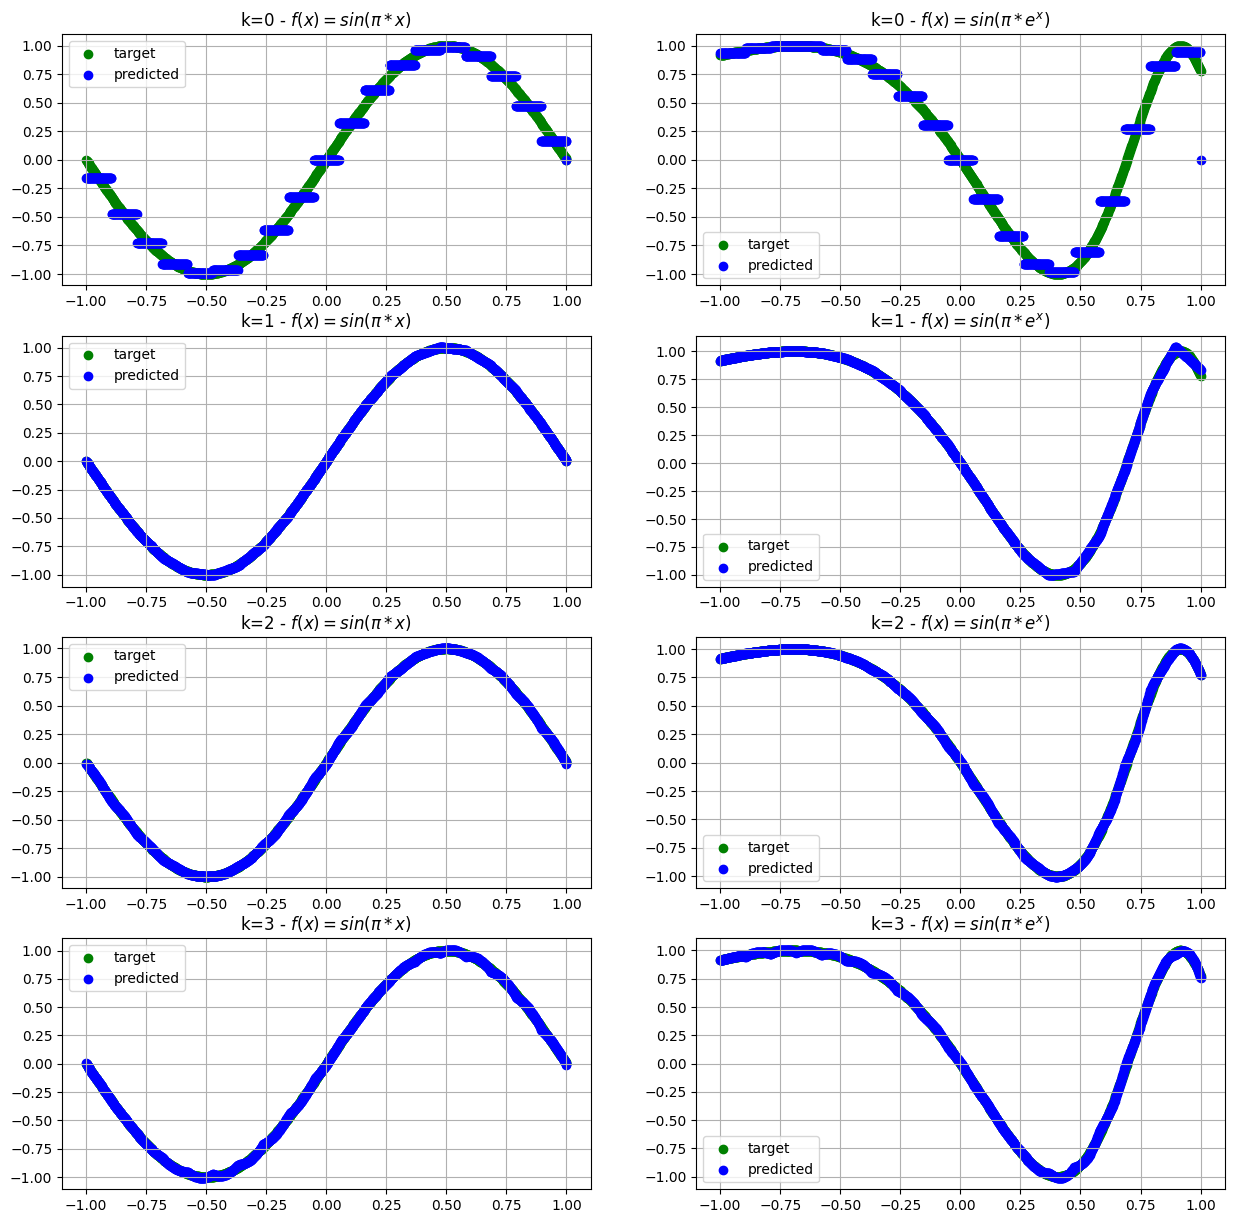

In [16]:
fns = []
fns += [(lambda x: torch.sin(torch.pi * x), '$f(x) = sin(\pi*x)$')]
fns += [(lambda x: torch.sin(torch.pi * torch.exp(x)), '$f(x) = sin(\pi*e^{x})$')]

all_basis = [
        (eval_basis_functions(x_, grid_, k=0), 'k=0'),
        (eval_basis_functions(x_, grid_, k=1), 'k=1'),
        (eval_basis_functions(x_, grid_, k=2), 'k=2'),
        (eval_basis_functions(x_, grid_, k=3), 'k=3')
]

fig, axs = plt.subplots(ncols=len(fns), nrows=len(all_basis), figsize=(15, 15), dpi=100)

for i in range(len(all_basis)):
    for j in range(len(fns)):

        ax = axs[i, j]
        value, label = all_basis[i]
        fn, fn_label = fns[j]

        coeff = torch.linalg.lstsq(value.squeeze(1), fn(x)).solution # find the coefficients
        y_pred = torch.einsum('i, ji -> j', coeff, value.squeeze(1)) # use these coefficients to evaluate y

        ax.scatter(x, fn(x), color='green', label='target')
        ax.scatter(x, y_pred, color='blue', label="predicted")

        ax.grid()
        ax.set_title(f"{label} - {fn_label}")
        ax.legend()

In [20]:
y_pred.shape, value.shape

(torch.Size([1000]), torch.Size([1000, 1, 22]))

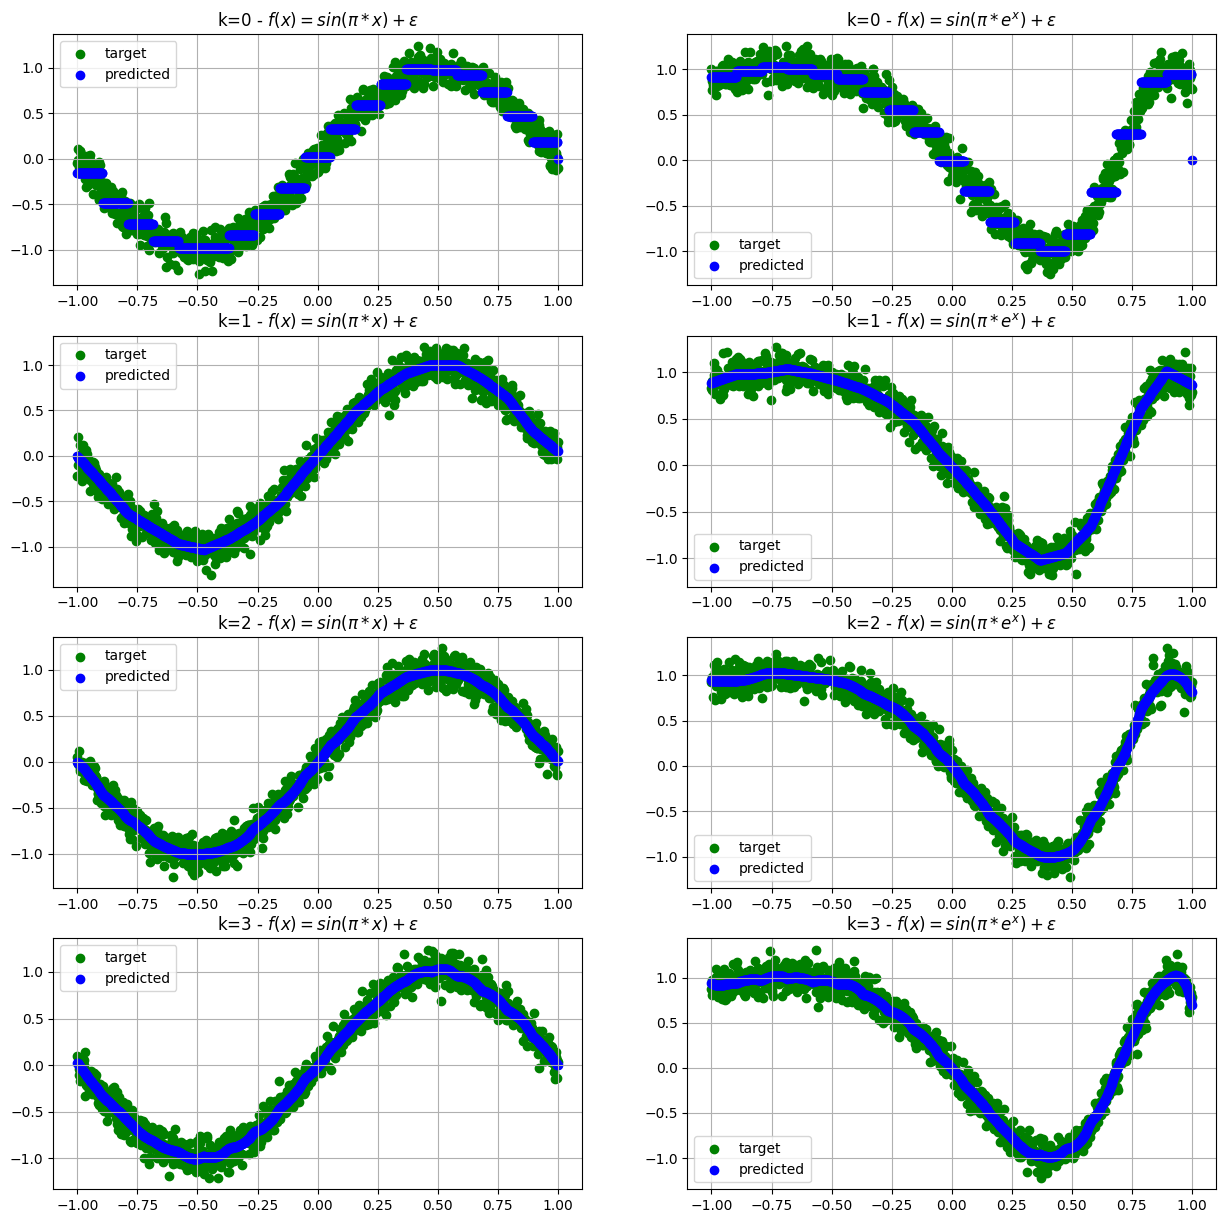

In [21]:
fns = []
fns += [(lambda x: torch.sin(torch.pi * x) + 0.1 * torch.randn(x.shape), '$f(x) = sin(\pi*x) + \epsilon$')]
fns += [(lambda x: torch.sin(torch.pi * torch.exp(x)) + 0.1 * torch.randn(x.shape), '$f(x) = sin(\pi*e^{x}) + \epsilon$')]

all_basis = [
        (eval_basis_functions(x_, grid_, k=0), 'k=0'),
        (eval_basis_functions(x_, grid_, k=1), 'k=1'),
        (eval_basis_functions(x_, grid_, k=2), 'k=2'),
        (eval_basis_functions(x_, grid_, k=3), 'k=3')
]

fig, axs = plt.subplots(ncols=len(fns), nrows=len(all_basis), figsize=(15, 15), dpi=100)

for i in range(len(all_basis)):
    for j in range(len(fns)):

        ax = axs[i, j]
        value, label = all_basis[i]
        fn, fn_label = fns[j]

        y_target = fn(x)
        coeff = torch.linalg.lstsq(value.squeeze(1), y_target).solution # find the coefficients
        y_pred = torch.einsum('i, ji -> j', coeff, value.squeeze(1)) # use these coefficients to evaluate y

        ax.scatter(x, y_target, color='green', label='target')
        ax.scatter(x, y_pred, color='blue', label="predicted")

        ax.grid()
        ax.set_title(f"{label} - {fn_label}")
        ax.legend()